# 07 Limitations And Data Budget

This notebook answers the final practical question: how much headroom is likely left, and where does the current thesis package still remain scientifically limited?

**Questions answered here**
- Are we still on the steep part of the paired-label curve?
- How much performance is lost under family-unseen transfer?
- Which limitations are methodological, and which are data-limited?


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def _find_thesis_root():
    cwd = Path.cwd().resolve()
    direct = [cwd, *cwd.parents]
    nested = [candidate / "thesis" for candidate in direct]
    for candidate in [*direct, *nested]:
        if (candidate / "THESIS_BLUEPRINT.md").exists() and (candidate / "src" / "qc_thesis" / "__init__.py").exists():
            return candidate
    raise FileNotFoundError("Could not find thesis root from notebook session")

ROOT = _find_thesis_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from qc_thesis import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
apply_thesis_style()

fig_dir, table_dir = notebook_output_dirs("07_limitations_and_data_budget")
bundle = get_limitations_bundle()
fpos_progress = build_benchmark_progress_table("fpos")
fmiss_progress = build_benchmark_progress_table("fmiss")


## 1. Label-budget evidence

The thesis should make the small-data regime visible. If the curve is still rising steeply, then the current benchmark is probably data-limited rather than fully saturated.


,target,variant_id,budget_rows,repeats,mean_mae,std_mae,mean_r2,std_r2,mean_bias,mean_subset_recordings
0,fmiss,contextual_paired_only_lightgbm,20,2,0.262189,0.001270,-0.397955,0.387429,-0.113492,3.0
1,fmiss,contextual_paired_only_lightgbm,60,2,0.223057,0.008807,0.039690,0.075600,-0.002847,8.0
2,fmiss,contextual_paired_only_lightgbm,107,1,0.157024,0.000000,0.439048,0.000000,-0.028227,14.0
3,fmiss,source_reweighted_fullctx_lightgbm,20,2,0.262189,0.001270,-0.397955,0.387429,-0.113492,3.0
4,fmiss,source_reweighted_fullctx_lightgbm,60,2,0.219513,0.000345,0.046459,0.139871,-0.011129,8.0
5,fmiss,source_reweighted_fullctx_lightgbm,107,1,0.155062,0.000000,0.474207,0.000000,-0.021718,14.0
6,fpos,contextual_paired_only_lightgbm,20,2,0.278224,0.081966,-1.012368,0.433966,0.054474,3.0
7,fpos,contextual_paired_only_lightgbm,60,2,0.165025,0.008682,0.193924,0.024399,0.033418,8.0
8,fpos,contextual_paired_only_lightgbm,107,1,0.127299,0.000000,0.487338,0.000000,-0.044440,14.0
9,fpos,embed_nommd_fullctx_lightgbm_filtered,20,2,0.278224,0.081966,-1.012368,0.433966,0.054474,3.0


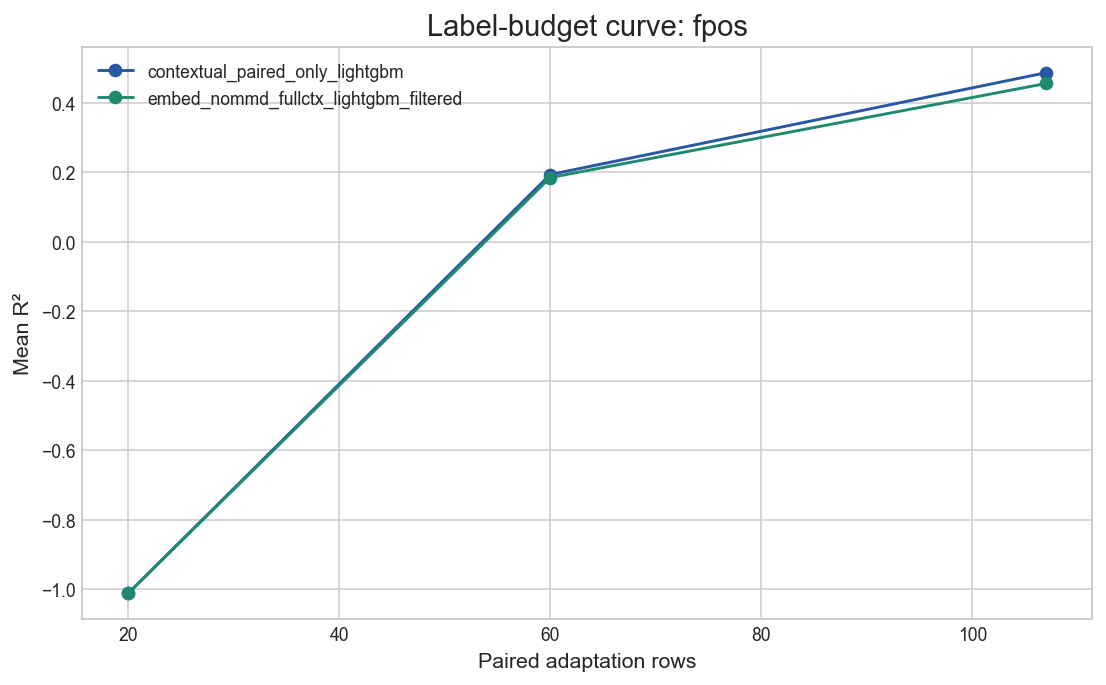

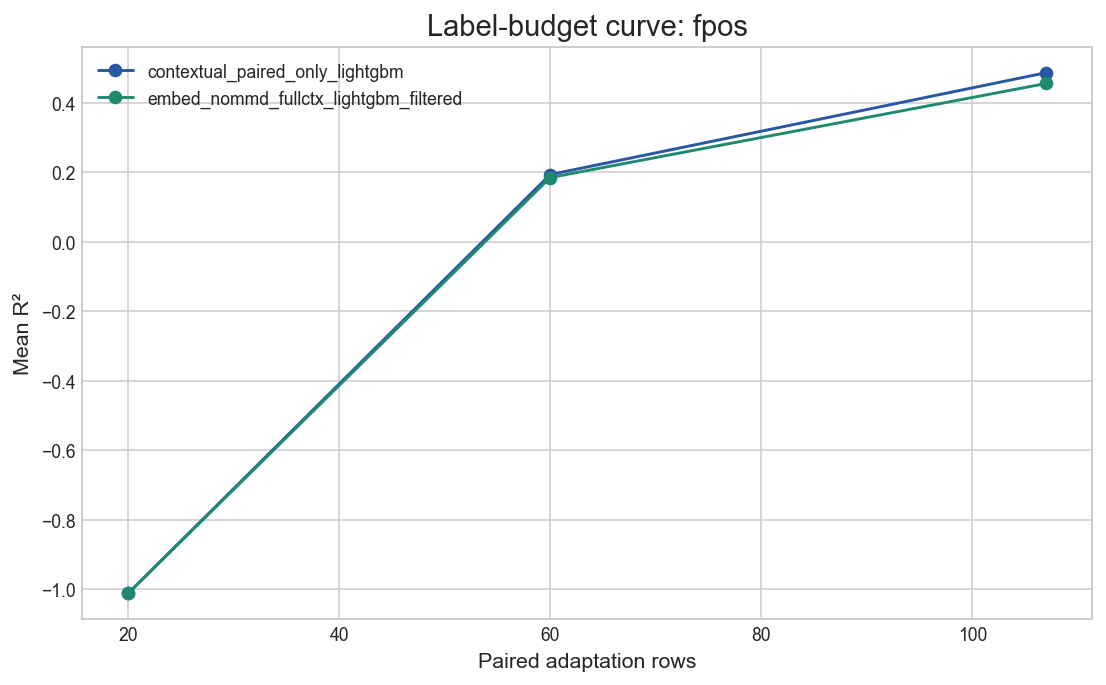

In [2]:
display(bundle.label_budget)
save_table(bundle.label_budget, table_dir, "label_budget_summary")
fig, _ = plot_label_budget(bundle.label_budget, target="fpos")
save_figure(fig, fig_dir, "label_budget_fpos")
fig


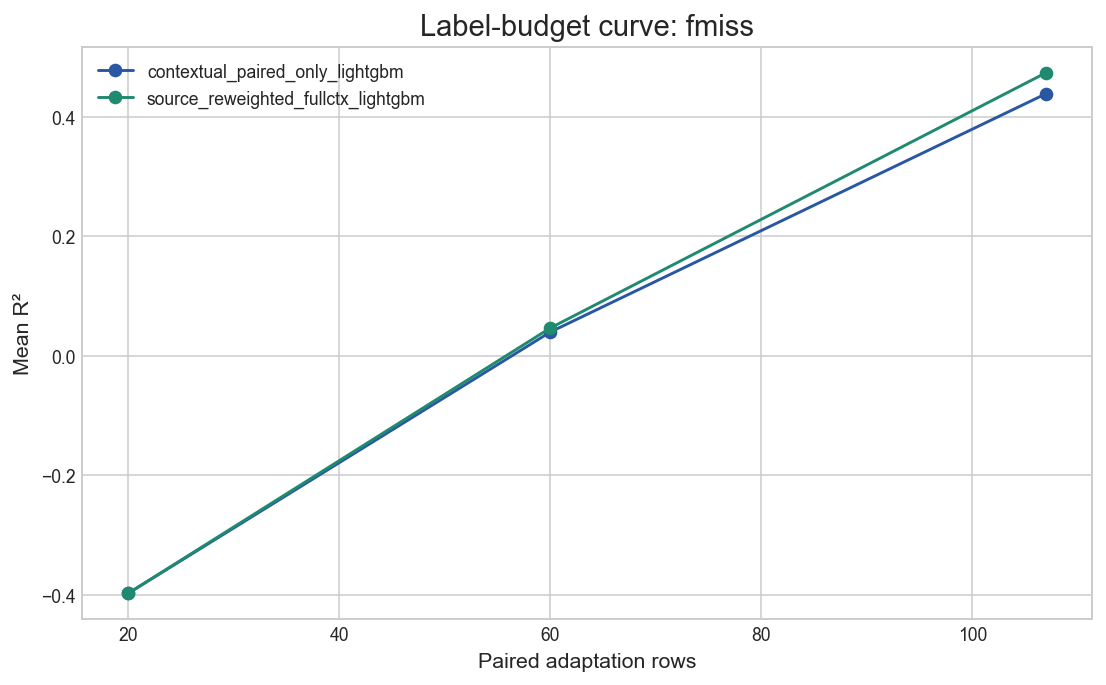

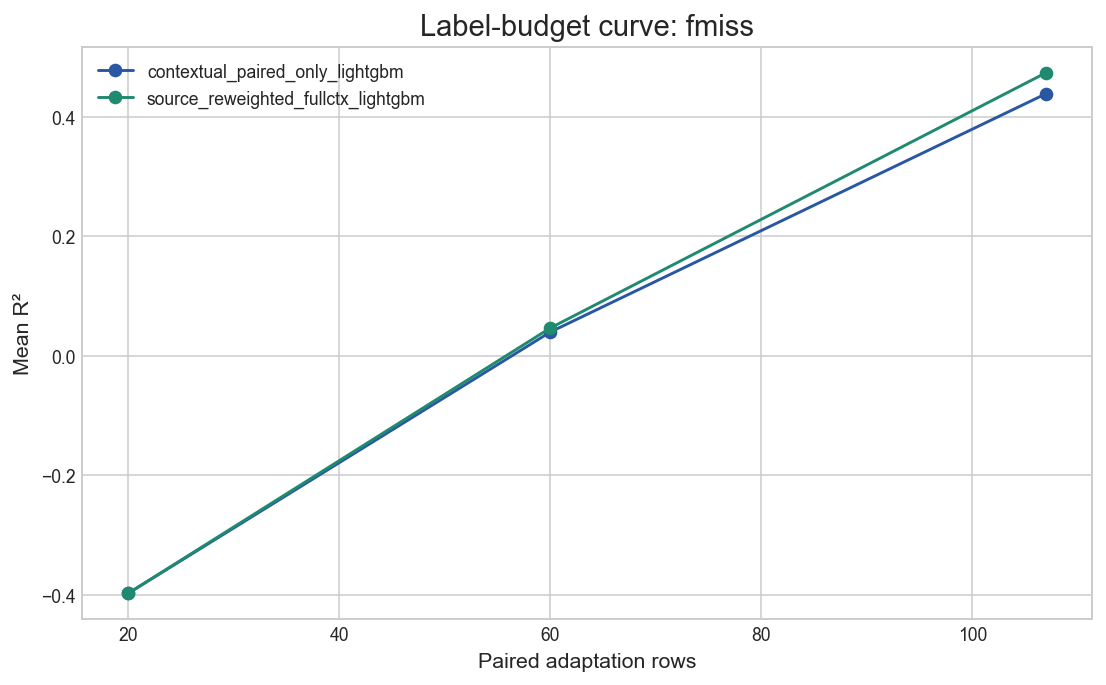

In [3]:
fig, _ = plot_label_budget(bundle.label_budget, target="fmiss")
save_figure(fig, fig_dir, "label_budget_fmiss")
fig


## 2. Family-held-out robustness

The main benchmark optimizes recording-disjoint transfer. This section reports the explicit penalty for requiring generalization to an unseen paired family.


,variant_id,macro_mae,macro_r2,weighted_mae,weighted_r2,worst_family_r2,best_family_r2
0,reference_anchor_stack_xgboost,0.125455,0.452724,0.131071,0.423981,0.293988,0.546858
1,wf_embed_anchor_stack_xgboost,0.122189,0.438568,0.126716,0.411617,0.148179,0.695184


,held_out_family,variant_id,mae,r2,bias,n_test_rows,n_test_recordings,pseudo_rows
0,PAIRED_BOYDEN,reference_anchor_stack_xgboost,0.074722,0.293988,-0.003118,43,4,193
1,PAIRED_CRCNS_HC1,reference_anchor_stack_xgboost,0.167210,0.538221,-0.064518,22,4,256
2,PAIRED_ENGLISH,reference_anchor_stack_xgboost,0.185688,0.351366,-0.009768,71,13,204
3,PAIRED_KAMPFF,reference_anchor_stack_xgboost,0.131304,0.546858,0.067875,35,4,213
4,PAIRED_MEA64C_YGER,reference_anchor_stack_xgboost,0.068349,0.533186,0.037329,36,4,182
5,PAIRED_BOYDEN,wf_embed_anchor_stack_xgboost,0.075131,0.148179,0.011304,43,4,193
6,PAIRED_CRCNS_HC1,wf_embed_anchor_stack_xgboost,0.178838,0.483317,-0.074358,22,4,256
7,PAIRED_ENGLISH,wf_embed_anchor_stack_xgboost,0.180457,0.362484,0.018255,71,13,204
8,PAIRED_KAMPFF,wf_embed_anchor_stack_xgboost,0.101993,0.695184,0.042196,35,4,213
9,PAIRED_MEA64C_YGER,wf_embed_anchor_stack_xgboost,0.074528,0.503675,0.037297,36,4,182


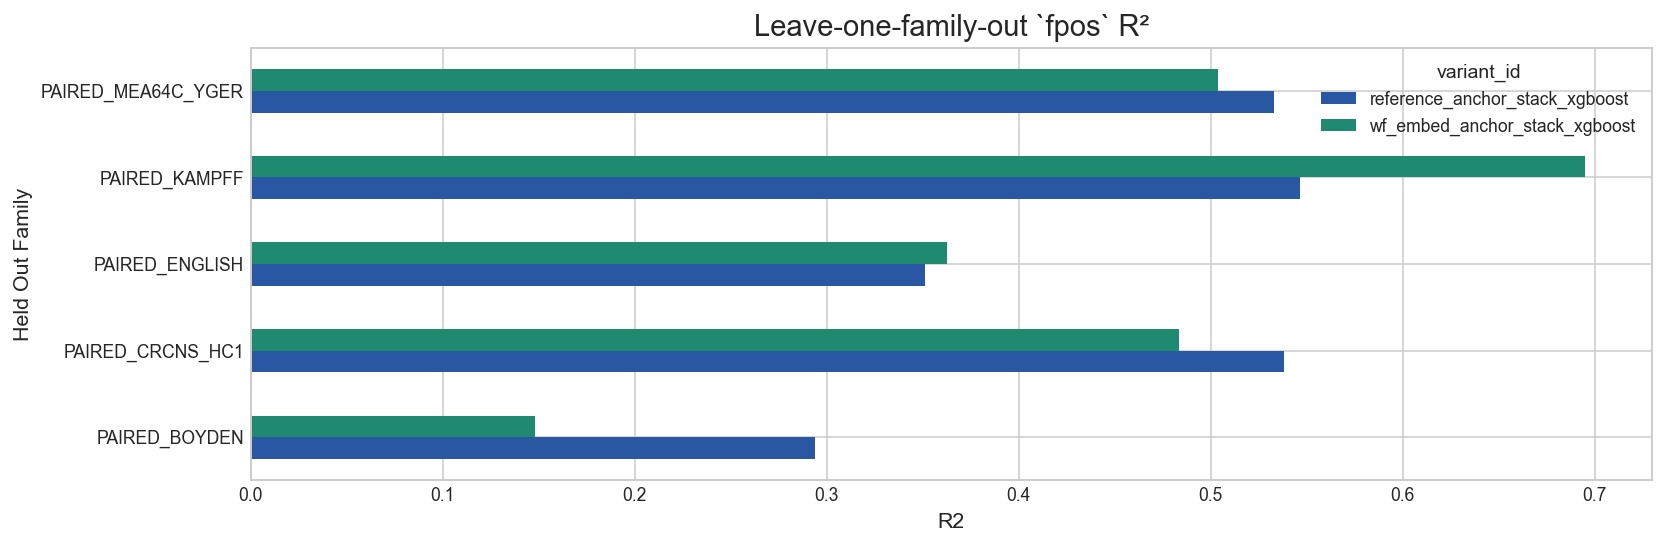

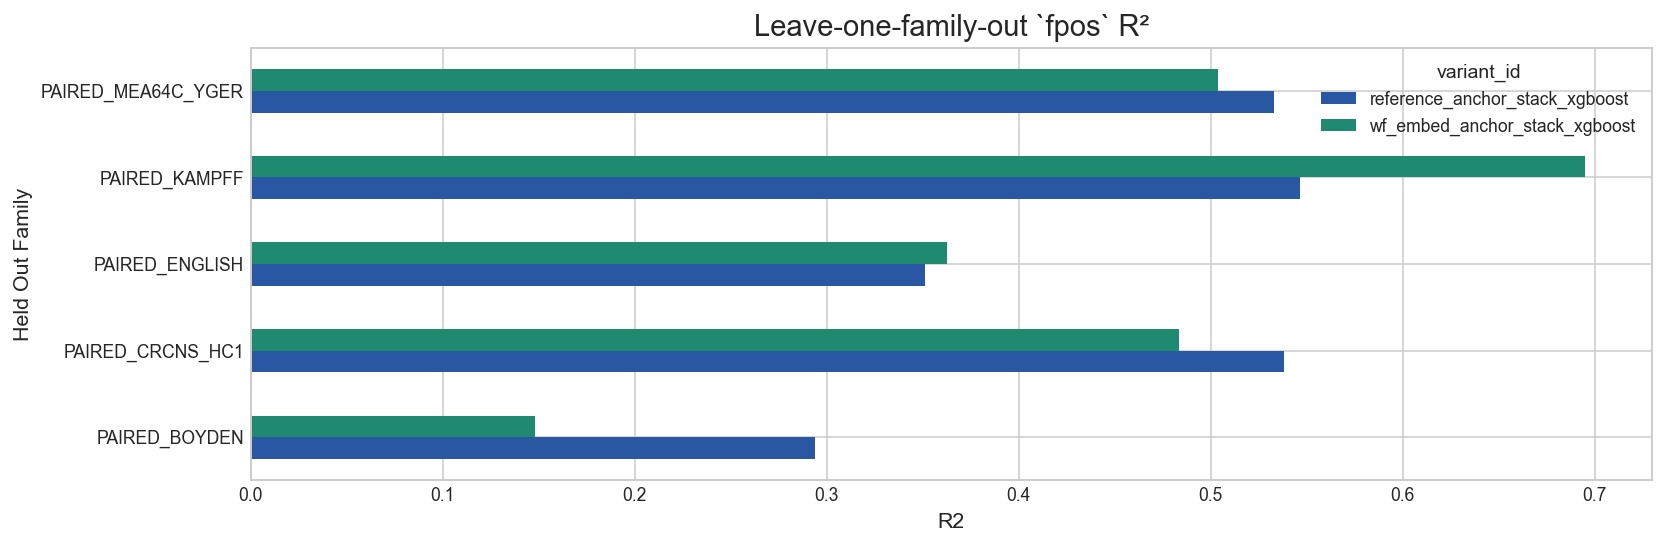

In [4]:
display(bundle.lofo_aggregate)
display(bundle.lofo_family)
save_table(bundle.lofo_aggregate, table_dir, "leave_one_family_aggregate")
save_table(bundle.lofo_family, table_dir, "leave_one_family_by_family")
fig, _, _ = plot_group_metric(bundle.lofo_family, group_col="held_out_family", metric="r2", title="Leave-one-family-out `fpos` R²")
save_figure(fig, fig_dir, "leave_one_family_r2")
fig


## 3. What the current results imply about headroom

The table below puts the current best results next to their simpler transfer baselines. It is not a theoretical upper bound, but it does show that there is still room between “basic transfer” and “current best”.


In [5]:
basic_fpos = fpos_progress.loc[fpos_progress["recipe_id"] == "fpos_hybrid_plus_paired"].iloc[0]
final_fpos = fpos_progress.sort_values("r2", ascending=False).iloc[0]
basic_fmiss = fmiss_progress.loc[fmiss_progress["recipe_id"] == "fmiss_hybrid_residual"].iloc[0]
final_fmiss = fmiss_progress.sort_values("r2", ascending=False).iloc[0]
headroom = pd.DataFrame([
    {"target": "fpos", "basic_transfer_r2": basic_fpos["r2"], "current_best_r2": final_fpos["r2"], "gain_r2": final_fpos["r2"] - basic_fpos["r2"]},
    {"target": "fmiss", "basic_transfer_r2": basic_fmiss["r2"], "current_best_r2": final_fmiss["r2"], "gain_r2": final_fmiss["r2"] - basic_fmiss["r2"]},
])
display(headroom)
save_table(headroom, table_dir, "headroom_summary")


,target,basic_transfer_r2,current_best_r2,gain_r2
0,fpos,0.358539,0.547852,0.189313
1,fmiss,0.212802,0.484977,0.272175


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/thesis/tables/07_limitations_and_data_budget/headroom_summary.csv')

In [6]:
display(Markdown(
    """
## Limitation summary

- The paired labeled pool is still small enough that label-budget curves matter.
- Leave-one-family-out performance remains clearly worse than the main benchmark, so family-unseen robustness is not solved.
- The strongest positive result is currently clearer for `fpos` than for `fmiss`.
- The most plausible next gains should come from richer spatial/template/drift information, not from more generic backend tinkering.
"""
))



## Limitation summary

- The paired labeled pool is still small enough that label-budget curves matter.
- Leave-one-family-out performance remains clearly worse than the main benchmark, so family-unseen robustness is not solved.
- The strongest positive result is currently clearer for `fpos` than for `fmiss`.
- The most plausible next gains should come from richer spatial/template/drift information, not from more generic backend tinkering.
